# Electric drives, part 3: thermal coupling and torque derating

A motor's true limit is rarely voltage or even current — it is *heat*. Copper
losses warm the windings; the resistance climbs with temperature (more loss); the
magnets weaken (less torque). Push too hard and the loss-temperature loop runs
away. This notebook couples Part 1's PMSM to a thermal model, derates $R$ and
$\lambda_m$ with winding temperature, and runs the fast electrical loop and the
slow thermal loop together as a multi-rate system — then finds the current at
which the machine thermally runs away.

**By the end you will be able to:**
1. Build a lumped-RC thermal block and validate its steady state and time constant.
2. Make a PMSM whose $R(T)$ and $\lambda_m(T)$ derate with winding temperature.
3. Run the coupled electrical+thermal system and watch field-oriented control
   raise $i_q$ to hold torque as the magnet weakens.
4. Derive and verify the **thermal-runaway current** $i_\mathrm{crit}$.

*Reading time ~25 min · runtime ~2 min on CPU.*

> **Position in the series.** Uses Part 1's `PMSM` (now temperature-dependent) and
> Part 2's FOC controller (re-inlined). Part 4 will calibrate the thermal and
> electrical parameters from data; Part 5 turns the runaway margin into a design
> spec under uncertainty.

> **Out of scope, on purpose.** Spatially-distributed thermal models (we use a
> single lumped node — a multi-node network is a natural extension), iron/eddy
> losses beyond a lumped copper term, and active thermal foldback protection
> (left as the headline exercise).

In [1]:
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from jax import config as _jax_config
_jax_config.update("jax_enable_x64", True)
import jax, jax.numpy as jnp
import jaxonomy
from jaxonomy import DiagramBuilder, LeafSystem, simulate, SimulatorOptions
from jaxonomy.library import Constant
from jaxonomy.framework import DependencyTicket
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)
np.random.seed(0)

# machine + thermal/derating parameters
PARAMS = dict(R=0.45, Ld=3.2e-3, Lq=5.8e-3, lam=0.0533, p=4.0, J=1.2e-3, B=8.0e-5)
ALPHA, BETA = 0.004, 0.0011        # copper R tempco, NdFeB flux tempco [1/K]
T_REF, T_AMB = 25.0, 25.0          # degC
C_TH, R_TH = 30.0, 0.30            # J/K, K/W  -> thermal tau = 9 s
V_DC = 48.0; V_LIM = V_DC/np.sqrt(3.0)
Kt0 = 1.5*PARAMS["p"]*PARAMS["lam"]

def R_of_T(T):   return PARAMS["R"]*(1.0 + ALPHA*(T - T_REF))
def lam_of_T(T): return PARAMS["lam"]*(1.0 - BETA*(T - T_REF))
def Kt_of_T(T):  return 1.5*PARAMS["p"]*lam_of_T(T)
print(f"jaxonomy {jaxonomy.__version__} | thermal tau = R_th*C_th = {R_TH*C_TH:.0f} s | Kt(25C)={Kt0:.4f}")

jaxonomy 2.2.0 | thermal tau = R_th*C_th = 9 s | Kt(25C)=0.3198


## 1 · A lumped-RC thermal model

The simplest faithful winding model is a single thermal mass $C_\mathrm{th}$
[J/K] losing heat to ambient through a resistance $R_\mathrm{th}$ [K/W]:

$$ C_\mathrm{th}\,\dot T = P_\mathrm{loss} - \frac{T - T_\mathrm{amb}}{R_\mathrm{th}}. $$

(A causal `LeafSystem` is the robust choice here — coupling a causal motor ODE to
an *acausal* thermal network needs a flow/potential bridge that is overkill for
one node.) Its steady state is $T_{ss}=T_\mathrm{amb}+P_\mathrm{loss}R_\mathrm{th}$
and its time constant is $\tau=R_\mathrm{th}C_\mathrm{th}$ — both checked below.

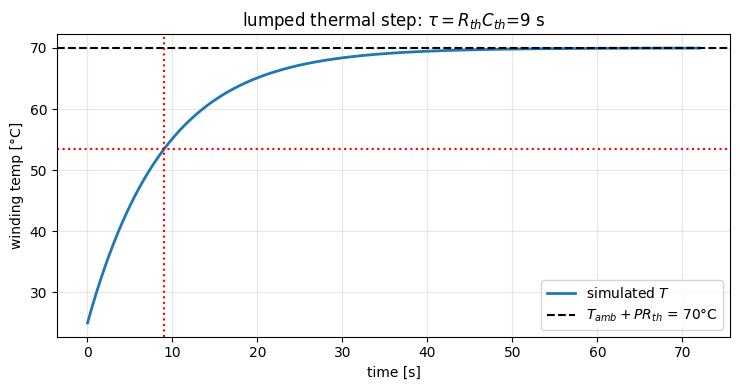

T_end=69.98°C (pred 70.00);  T(tau)/rise=0.632


In [2]:
class LumpedThermal(LeafSystem):
    """dT/dt = (P_loss - (T - T_amb)/R_th)/C_th.  input0 = P_loss, output = T."""
    def __init__(self, C_th=C_TH, R_th=R_TH, T_amb=T_AMB, T0=T_AMB, name="thermal"):
        super().__init__(name=name)
        self.C_th, self.R_th, self.T_amb = C_th, R_th, T_amb
        self.declare_input_port(name="P_loss")
        self.declare_continuous_state(default_value=float(T0), ode=self._ode, requires_inputs=True)
        self.declare_output_port(lambda t, x, *u: x.continuous_state, name="T",
                                 prerequisites_of_calc=[DependencyTicket.xc], requires_inputs=False)
    def _ode(self, time, state, *inputs):
        (P,) = inputs
        T = state.continuous_state
        return (P - (T - self.T_amb)/self.R_th)/self.C_th

def thermal_step(P, t_end, n=4000):
    b = DiagramBuilder()
    th = b.add(LumpedThermal()); src = b.add(Constant(jnp.asarray(float(P)), name="P"))
    b.connect(src.output_ports[0], th.input_ports[0])
    diag = b.build(); ctx = diag.create_context()
    res = simulate(diag, ctx, (0.0, t_end), options=SimulatorOptions(max_major_step_length=t_end/n),
                   recorded_signals={"T": th.output_ports[0]})
    return np.asarray(res.time), np.asarray(res.outputs["T"])

P_demo = 150.0
t, T = thermal_step(P_demo, 8*R_TH*C_TH)
T_ss = T_AMB + P_demo*R_TH; tau = R_TH*C_TH
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(t, T, lw=2, label="simulated $T$")
ax.axhline(T_ss, color="k", ls="--", label=f"$T_{{amb}}+P R_{{th}}$ = {T_ss:.0f}°C")
ax.axvline(tau, color="r", ls=":"); ax.axhline(T_AMB+0.632*(T_ss-T_AMB), color="r", ls=":")
ax.set_xlabel("time [s]"); ax.set_ylabel("winding temp [°C]")
ax.set_title(f"lumped thermal step: $\\tau=R_{{th}}C_{{th}}$={tau:.0f} s"); ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); plt.show()
print(f"T_end={T[-1]:.2f}°C (pred {T_ss:.2f});  T(tau)/rise={ (np.interp(tau,t,T)-T_AMB)/(T_ss-T_AMB):.3f}")
assert abs(T[-1]-T_ss) < 0.5 and abs((np.interp(tau,t,T)-T_AMB)/(T_ss-T_AMB) - (1-np.exp(-1))) < 0.02

**Figure 1.** The thermal step lands on $T_\mathrm{amb}+P R_\mathrm{th}$ and
crosses 63.2 % of the rise at exactly $t=\tau$ — a textbook first-order lag.

## 2 · Temperature-dependent machine

Two physical derating laws (both linearised about $T_\mathrm{ref}=25$°C):

$$ R(T) = R_0\,[1 + \alpha (T-T_\mathrm{ref})], \qquad
   \lambda_m(T) = \lambda_{m0}\,[1 - \beta (T-T_\mathrm{ref})]. $$

Copper's $\alpha\approx0.004\,\mathrm{K^{-1}}$ makes losses *grow* with heat (the
seed of runaway); the NdFeB magnet's $\beta\approx0.0011\,\mathrm{K^{-1}}$ shrinks
the flux, so the torque constant $K_t(T)=\tfrac32 p\,\lambda_m(T)$ falls. The PMSM
block reads its winding temperature on a second input port and outputs its copper
loss $P_\mathrm{loss}=\tfrac32 R(T)(i_d^2+i_q^2)$ to drive the thermal node.

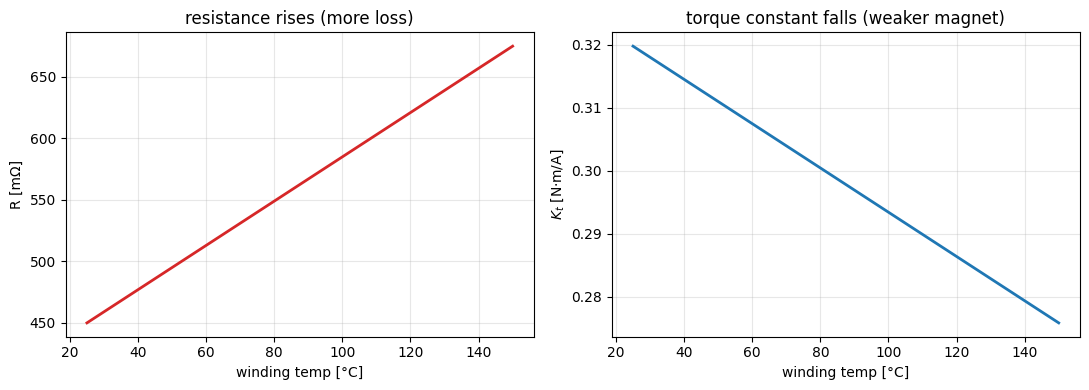

at 125°C: R +40%, Kt -11%


In [3]:
class PMSMThermal(LeafSystem):
    """Interior PMSM with temperature derating.
    inputs: 0 = v_dq[2], 1 = T_winding.  outputs: 0 = state x[4], 1 = P_loss."""
    def __init__(self, x0=None, T_load=0.0, name="pmsm"):
        super().__init__(name=name)
        self.p = dict(PARAMS); self.T_load = float(T_load)
        if x0 is None: x0 = jnp.zeros(4)
        self.declare_input_port(name="v_dq"); self.declare_input_port(name="T")
        self.declare_continuous_state(default_value=jnp.asarray(x0, float), ode=self._ode, requires_inputs=True)
        self.declare_continuous_state_output(name="x")
        self.declare_output_port(self._ploss, name="P_loss", requires_inputs=True)
    def _ode(self, time, state, *inp):
        x = state.continuous_state; v_dq = inp[0]; T = jnp.atleast_1d(inp[1])[0]
        i_d, i_q, w_m, _ = x; v_d, v_q = v_dq[0], v_dq[1]; w_e = self.p["p"]*w_m
        R, lam = R_of_T(T), lam_of_T(T)
        di_d = (v_d - R*i_d + w_e*self.p["Lq"]*i_q)/self.p["Ld"]
        di_q = (v_q - R*i_q - w_e*(self.p["Ld"]*i_d + lam))/self.p["Lq"]
        Te = 1.5*self.p["p"]*(lam*i_q + (self.p["Ld"]-self.p["Lq"])*i_d*i_q)
        return jnp.array([di_d, di_q, (Te - self.p["B"]*w_m - self.T_load)/self.p["J"], w_m])
    def _ploss(self, time, state, *inp):
        x = state.continuous_state; T = jnp.atleast_1d(inp[1])[0]
        return 1.5*R_of_T(T)*(x[0]**2 + x[1]**2)

# derating laws figure
Ts = np.linspace(25, 150, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Ts, [R_of_T(T)*1e3 for T in Ts], lw=2, color="C3")
ax[0].set_title("resistance rises (more loss)"); ax[0].set_ylabel("R [mΩ]")
ax[1].plot(Ts, [Kt_of_T(T) for T in Ts], lw=2, color="C0")
ax[1].set_title("torque constant falls (weaker magnet)"); ax[1].set_ylabel("$K_t$ [N·m/A]")
for a in ax: a.set_xlabel("winding temp [°C]"); a.grid(alpha=.3)
fig.tight_layout(); plt.show()
print(f"at 125°C: R +{100*(R_of_T(125)/PARAMS['R']-1):.0f}%, Kt -{100*(1-Kt_of_T(125)/Kt0):.0f}%")
assert R_of_T(125) > PARAMS["R"] and Kt_of_T(125) < Kt0

**Figure 2.** Over a 100 °C rise the winding resistance climbs ~40 % while
the torque constant drops ~11 %. The first feeds the loss back into the heat
equation; the second forces the controller to work harder for the same torque.

## 3 · The coupled system under control

Now the full multi-rate loop: Part 2's FOC holds a **low speed against a heavy
load** — the classic thermal-stress case (a robot joint pushing, a vehicle on a
hill). The fast electrical loop settles in milliseconds; the thermal node drifts
over tens of seconds. As the magnet derates, watch the controller *automatically
raise $i_q$* to hold the commanded speed — and the copper loss creep up with it.

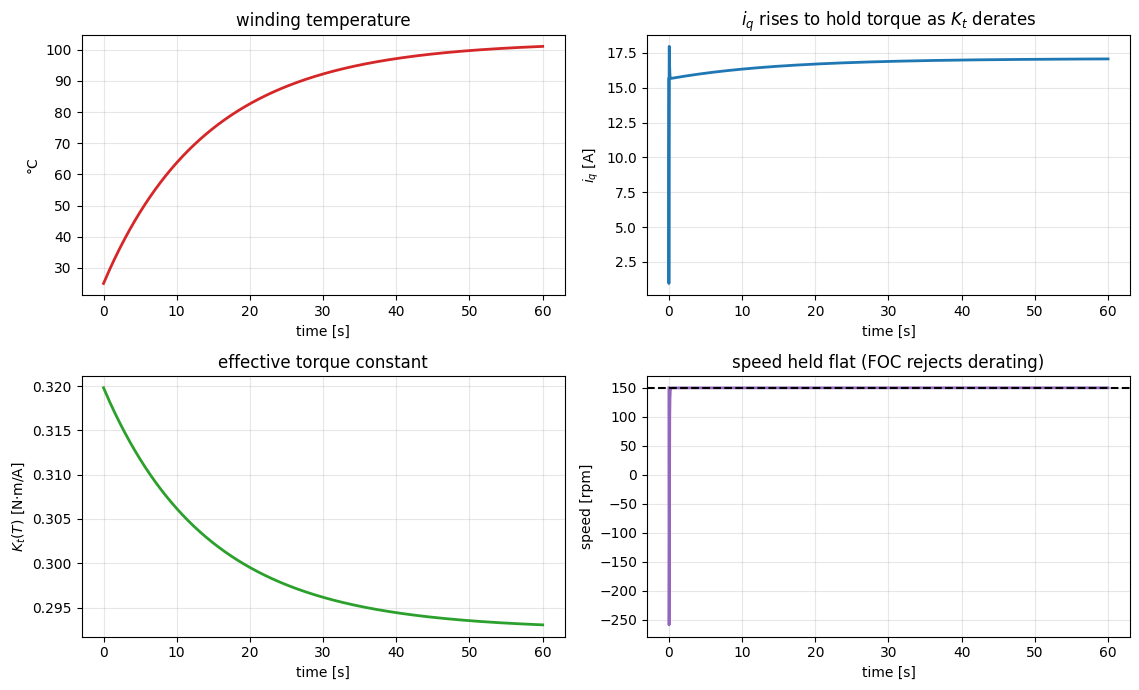

T 25->101°C | Kt 0.3198->0.2930 | iq 15.63->17.07 A | speed held 150 rpm


In [4]:
def foc_gains(bw_i_hz, bw_w_hz):
    wi = 2*np.pi*bw_i_hz; ww = 2*np.pi*bw_w_hz
    return dict(Kp_d=PARAMS["Ld"]*wi, Ki_d=PARAMS["R"]*wi, Kp_q=PARAMS["Lq"]*wi, Ki_q=PARAMS["R"]*wi,
                Kp_w=2*ww*PARAMS["J"]/Kt0, Ki_w=ww*ww*PARAMS["J"]/Kt0)

class FOCController(LeafSystem):
    """Speed->current FOC with dq decoupling using NOMINAL (cold) parameters."""
    def __init__(self, gains, iq_max=60.0, name="foc"):
        super().__init__(name=name)
        self.g = dict(gains); self.p = dict(PARAMS); self.iq_max = iq_max
        self.declare_input_port(name="x"); self.declare_input_port(name="w_ref")
        self.declare_continuous_state(default_value=jnp.zeros(3), ode=self._ode, requires_inputs=True)
        self.declare_output_port(self._out, name="v_dq", requires_inputs=True,
                                 prerequisites_of_calc=[DependencyTicket.xc])
    def _cmds(self, xi, x, w_ref):
        i_d, i_q, w_m, _ = x; e_w = w_ref - w_m
        iq_ref = jnp.clip(self.g["Kp_w"]*e_w + self.g["Ki_w"]*xi[2], -self.iq_max, self.iq_max)
        return (0.0 - i_d), (iq_ref - i_q), e_w, i_d, i_q, w_m
    def _ode(self, time, state, *inp):
        x, w_ref = inp[0], jnp.atleast_1d(inp[1])[0]
        e_d, e_q, e_w, *_ = self._cmds(state.continuous_state, x, w_ref)
        return jnp.array([e_d, e_q, e_w])
    def _out(self, time, state, *inp):
        xi = state.continuous_state; x, w_ref = inp[0], jnp.atleast_1d(inp[1])[0]
        e_d, e_q, e_w, i_d, i_q, w_m = self._cmds(xi, x, w_ref); w_e = self.p["p"]*w_m
        vd = self.g["Kp_d"]*e_d + self.g["Ki_d"]*xi[0] - w_e*self.p["Lq"]*i_q
        vq = self.g["Kp_q"]*e_q + self.g["Ki_q"]*xi[1] + w_e*(self.p["Ld"]*i_d + self.p["lam"])
        mag = jnp.sqrt(vd*vd + vq*vq) + 1e-12; s = jnp.minimum(1.0, V_LIM/mag)
        return jnp.array([vd*s, vq*s])

def run_story(rpm, T_load, t_end=60.0):
    w_ref = rpm*2*np.pi/60
    x0 = jnp.array([0.0, T_load/Kt0, w_ref, 0.0])      # start at speed, current ~ feedforward
    b = DiagramBuilder()
    m = b.add(PMSMThermal(x0=x0, T_load=T_load))
    th = b.add(LumpedThermal(T0=T_AMB))
    c = b.add(FOCController(foc_gains(200, 6)))
    wref = b.add(Constant(jnp.asarray(float(w_ref)), name="w_ref"))
    b.connect(c.output_ports[0], m.input_ports[0]); b.connect(th.output_ports[0], m.input_ports[1])
    b.connect(m.output_ports[1], th.input_ports[0]); b.connect(m.output_ports[0], c.input_ports[0])
    b.connect(wref.output_ports[0], c.input_ports[1])
    diag = b.build(); ctx = diag.create_context()
    res = simulate(diag, ctx, (0.0, t_end),
                   options=SimulatorOptions(max_major_step_length=t_end/2000, buffer_length=400000),
                   recorded_signals={"x": m.output_ports[0], "T": th.output_ports[0], "P": m.output_ports[1]})
    return np.asarray(res.time), np.asarray(res.outputs["x"]), np.asarray(res.outputs["T"]), np.asarray(res.outputs["P"])

t, X, T, P = run_story(rpm=150, T_load=5.0)
rpm = X[:,2]*60/(2*np.pi); iq = X[:,1]
fig, ax = plt.subplots(2, 2, figsize=(11.5, 7))
ax[0,0].plot(t, T, lw=2, color="C3"); ax[0,0].set_title("winding temperature"); ax[0,0].set_ylabel("°C")
ax[0,1].plot(t, iq, lw=2); ax[0,1].set_title("$i_q$ rises to hold torque as $K_t$ derates"); ax[0,1].set_ylabel("$i_q$ [A]")
ax[1,0].plot(t, Kt_of_T(T), lw=2, color="C2"); ax[1,0].set_title("effective torque constant"); ax[1,0].set_ylabel("$K_t(T)$ [N·m/A]")
ax[1,1].plot(t, rpm, lw=2, color="C4"); ax[1,1].axhline(150, color="k", ls="--")
ax[1,1].set_title("speed held flat (FOC rejects derating)"); ax[1,1].set_ylabel("speed [rpm]")
for a in ax.ravel(): a.set_xlabel("time [s]"); a.grid(alpha=.3)
fig.tight_layout(); plt.show()
print(f"T {T[0]:.0f}->{T[-1]:.0f}°C | Kt {Kt_of_T(T[0]):.4f}->{Kt_of_T(T[-1]):.4f} "
      f"| iq {iq[0]:.2f}->{iq[-1]:.2f} A | speed held {rpm[-1]:.0f} rpm")
assert iq[-1] > iq[0] + 0.3            # controller compensates derating
assert abs(rpm[-1]-150) < 5            # speed regulated despite heating

**Figure 3.** As the winding heats from 25 °C, $K_t$ sags, so the speed
loop pushes $i_q$ up to keep the same torque — and the speed barely moves. This is
the coupling that matters in practice: a controller that *looks* fine cold can
quietly drive itself toward the thermal limit. The two timescales — millisecond
electrical, ~10-second thermal — are handled in one adaptive integration.

## 4 · Thermal runaway

The dangerous feedback: higher $T \Rightarrow$ higher $R(T) \Rightarrow$ higher
$P_\mathrm{loss}=\tfrac32 R(T)\,i^2 \Rightarrow$ higher $T$. At fixed current
magnitude $i$, the steady state solves
$\tfrac32 R_0[1+\alpha\Delta T]\,i^2 = \Delta T/R_\mathrm{th}$, which has a
*positive* solution only while

$$ \frac{1}{R_\mathrm{th}} > \tfrac32 R_0\,\alpha\,i^2
   \quad\Longleftrightarrow\quad
   i < i_\mathrm{crit} = \sqrt{\frac{1}{R_\mathrm{th}\,\tfrac32 R_0\,\alpha}}. $$

Below $i_\mathrm{crit}$ the temperature settles; above it, it diverges. We close
the loss→temperature loop with a fixed-current heat source and watch both sides
of the threshold.

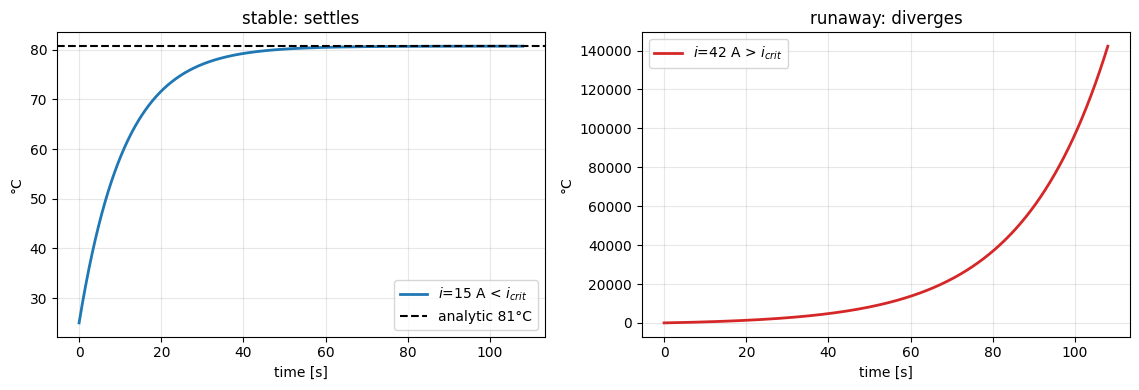

i_crit = 35.1 A | stable dT_sim=55.7 vs pred 55.7 | runaway T_end=142260°C


In [5]:
class CopperLoss(LeafSystem):
    """P_loss = 1.5 R(T) i^2 at fixed current magnitude. input0=T, output=P_loss."""
    def __init__(self, i_mag, name="loss"):
        super().__init__(name=name); self.i2 = float(i_mag)**2
        self.declare_input_port(name="T")
        self.declare_output_port(self._out, name="P_loss", requires_inputs=True)
    def _out(self, time, state, *inp):
        T = jnp.atleast_1d(inp[0])[0]
        return 1.5*R_of_T(T)*self.i2

def run_coupled(i_mag, t_end):
    b = DiagramBuilder(); th = b.add(LumpedThermal(T0=T_AMB)); ls = b.add(CopperLoss(i_mag))
    b.connect(ls.output_ports[0], th.input_ports[0]); b.connect(th.output_ports[0], ls.input_ports[0])
    diag = b.build(); ctx = diag.create_context()
    res = simulate(diag, ctx, (0.0, t_end), options=SimulatorOptions(max_major_step_length=t_end/3000, buffer_length=400000),
                   recorded_signals={"T": th.output_ports[0]})
    return np.asarray(res.time), np.asarray(res.outputs["T"])

i_crit = np.sqrt(1.0/(R_TH*1.5*PARAMS["R"]*ALPHA))
i_lo, i_hi = 15.0, 42.0
t_lo, T_lo = run_coupled(i_lo, 12*R_TH*C_TH)
t_hi, T_hi = run_coupled(i_hi, 12*R_TH*C_TH)
dT_pred = 1.5*PARAMS["R"]*i_lo**2 / (1.0/R_TH - 1.5*PARAMS["R"]*ALPHA*i_lo**2)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
ax[0].plot(t_lo, T_lo, lw=2, color="C0", label=f"$i$={i_lo:.0f} A < $i_{{crit}}$")
ax[0].axhline(T_AMB+dT_pred, color="k", ls="--", label=f"analytic {T_AMB+dT_pred:.0f}°C")
ax[0].set_title("stable: settles"); ax[0].set_ylabel("°C"); ax[0].legend()
ax[1].plot(t_hi, T_hi, lw=2, color="C3", label=f"$i$={i_hi:.0f} A > $i_{{crit}}$")
ax[1].set_title("runaway: diverges"); ax[1].set_ylabel("°C"); ax[1].legend()
for a in ax: a.set_xlabel("time [s]"); a.grid(alpha=.3)
fig.tight_layout(); plt.show()
print(f"i_crit = {i_crit:.1f} A | stable dT_sim={T_lo[-1]-T_AMB:.1f} vs pred {dT_pred:.1f} | runaway T_end={T_hi[-1]:.0f}°C")
assert abs((T_lo[-1]-T_AMB) - dT_pred)/dT_pred < 0.03
assert T_hi[-1] > T_lo[-1] + 100

**Figure 4.** Below $i_\mathrm{crit}\approx35$ A the winding settles on the
analytic steady state; above it the loss-temperature feedback wins and the
temperature diverges. $i_\mathrm{crit}$ is a hard design boundary — Part 5 treats
the margin to it as a reliability spec under parameter uncertainty.

## Failure modes

1. **Thermal runaway** (§4): sustained current above $i_\mathrm{crit}$ has no
   stable temperature — the motor cooks itself. Real drives prevent this with
   current/temperature foldback.
2. **Silent derating** (§3): a controller tuned cold slowly demands more current
   as the magnet weakens, walking the operating point toward the limit without
   any obvious symptom in the speed trace.
3. **Optimistic cooling**: underestimating $R_\mathrm{th}$ (better-than-real heat
   sinking) pushes the predicted $i_\mathrm{crit}$ too high — a dangerous error.

## Exercises

- **(Easy)** Halve $R_\mathrm{th}$ (better cooling) and recompute $i_\mathrm{crit}$;
  verify the coupled sim agrees.
- **(Medium)** Add a second thermal node (magnet vs winding) with conduction
  between them; which one limits first?
- **(Hard)** Implement thermal foldback: scale the $i_q$ limit down smoothly as
  $T\to T_\max$ and show it prevents runaway at $i>i_\mathrm{crit}$.
- **(Open)** Replace the lumped node with an acausal `HeatCapacitor`/`Insulator`
  network and reconcile the two against Fig 1.

## Next steps

**Part 4 — Calibration** stops assuming the parameters. It recovers $R$, $L_d$,
$L_q$, $\lambda_m$ (and the thermal $R_\mathrm{th}$, $C_\mathrm{th}$) from noisy
bench data by forward-mode system identification, with an identifiability check.

## References

1. P. Krause et al., *Analysis of Electric Machinery and Drive Systems*, Wiley-IEEE, 2013.
2. D. Staton, A. Boglietti, A. Cavagnino, "Solving the more difficult aspects of
   electric motor thermal analysis," *IEEE Trans. Energy Convers.*, 2005 —
   lumped-parameter thermal networks.
3. S. Ruoho et al., "Interdependence of demagnetization, loading, and temperature
   rise in a PM synchronous motor," *IEEE Trans. Magn.*, 2010 — magnet derating.